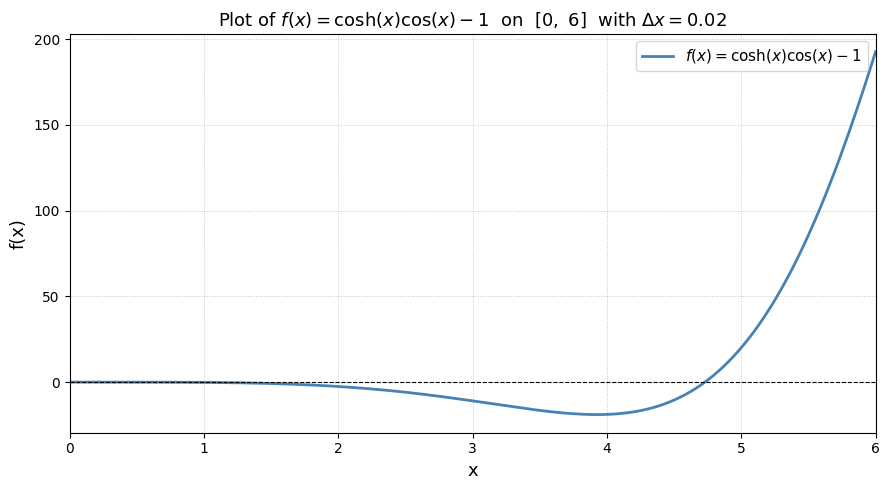

Ridder root: 4.7300407448627055
Newton Root: 4.730040744862704


In [37]:
import numpy as np
import matplotlib.pyplot as plt

# Generate x values from 0 to 6 with step size 0.02
x = np.arange(0.0, 6.0 + 0.02, 0.02)

# Define f(x) = cosh(x)*cos(x) - 1
f = np.cosh(x) * np.cos(x) - 1


# Plot
plt.figure(figsize=(9, 5))
plt.plot(x, f, color='steelblue', linewidth=2, label=r'$f(x) = \cosh(x)\cos(x) - 1$')

# Zero reference line
plt.axhline(y=0, color='black', linewidth=0.8, linestyle='--')

# Labels and formatting
plt.xlabel('x', fontsize=13)
plt.ylabel('f(x)', fontsize=13)
plt.title(r'Plot of $f(x) = \cosh(x)\cos(x) - 1$  on  $[0,\ 6]$  with $\Delta x = 0.02$', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', linewidth=0.7, alpha=0.7)
plt.xlim(0, 6)
plt.tight_layout()
plt.show()


def f(x):
    return np.cosh(x) * np.cos(x) - 1
## module error
''' err(string).
    Prints 'string' and terminates program.
'''
import sys
def err(string):
    print(string)
    input('Press return to exit')
    sys.exit(0)

## module ridder
''' root = ridder(f,a,b,tol=1.0e-9).
    Finds a root of f(x) = 0 with Ridder's method.
    The root must be bracketed in (a,b).
'''
import error
import math
from numpy import sign

def ridder(f,a,b,tol=1.0e-9):
    fa = f(a)
    if fa == 0.0: return a
    fb = f(b)
    if fb == 0.0: return b
    if sign(fa) == sign(fb): error.err('Root is not bracketed')
    for i in range(30):
      # Compute the improved root x from Ridder's formula
        c = 0.5*(a + b); fc = f(c)
        s = math.sqrt(fc**2 - fa*fb)
        if s == 0.0: return None
        dx = (c - a)*fc/s
        if (fa - fb) < 0.0: dx = -dx
        x = c + dx; fx = f(x)
      # Test for convergence
        if i > 0:
            if abs(x - xOld) < tol*max(abs(x),1.0): return x
        xOld = x
      # Re-bracket the root as tightly as possible
        if sign(fc) == sign(fx):
            if sign(fa)!= sign(fx): b = x; fb = fx
            else: a = x; fa = fx
        else:
            a = c; b = x; fa = fc; fb = fx
    return None
    print('Too many iterations')

a = 4
b = 5
print(f'Ridder root: {ridder(f,a,b,tol=1.0e-9)}')

## module newtonRaphson
''' root = newtonRaphson(f,df,a,b,tol=1.0e-9).
    Finds a root of f(x) = 0 by combining the Newton-Raphson
    method with bisection. The root must be bracketed in (a,b).
    Calls user-supplied functions f(x) and its derivative df(x).
'''
def newtonRaphson(f,df,a,b,tol=1.0e-9):
    import error
    from numpy import sign

    fa = f(a)
    if fa == 0.0: return a
    fb = f(b)
    if fb == 0.0: return b
    if sign(fa) == sign(fb): error.err('Root is not bracketed')
    x = 0.5*(a + b)
    for i in range(30):
        fx = f(x)
        if fx == 0.0: return x
      # Tighten the brackets on the root
        if sign(fa) != sign(fx): b = x
        else: a = x
      # Try a Newton-Raphson step
        dfx = df(x)
      # If division by zero, push x out of bounds
        try: dx = -fx/dfx
        except ZeroDivisionError: dx = b - a
        x = x + dx
      # If the result is outside the brackets, use bisection
        if (b - x)*(x - a) < 0.0:
            dx = 0.5*(b - a)
            x = a + dx
      # Check for convergence
        if abs(dx) < tol*max(abs(b),1.0): return x
    print('Too many iterations in Newton-Raphson')

def df(x):
    return np.cos(x)*np.sinh(x)-np.cosh(x)*np.sin(x)

print(f'Newton Root: {newtonRaphson(f,df,a,b,tol=1.0e-9)}')




In [38]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
    return np.sin(x)+3*np.cos(x)-2

def df(x):
    return np.cos(x)-3*np.sin(x)
a = 0
b = 2


def newtonRaphson(f,df,a,b,tol=1.0e-7):
    import error
    from numpy import sign

    fa = f(a)
    if fa == 0.0: return a
    fb = f(b)
    if fb == 0.0: return b
    if sign(fa) == sign(fb): error.err('Root is not bracketed')
    x = 0.5*(a + b)
    for i in range(30):
        fx = f(x)
        if fx == 0.0: return x
      # Tighten the brackets on the root
        if sign(fa) != sign(fx): b = x
        else: a = x
      # Try a Newton-Raphson step
        dfx = df(x)
      # If division by zero, push x out of bounds
        try: dx = -fx/dfx
        except ZeroDivisionError: dx = b - a
        x = x + dx
      # If the result is outside the brackets, use bisection
        if (b - x)*(x - a) < 0.0:
            dx = 0.5*(b - a)
            x = a + dx
      # Check for convergence
        if abs(dx) < tol*max(abs(b),1.0): return x
    print('Too many iterations in Newton-Raphson')

print(f'Newton Root 1: {newtonRaphson(f,df,a,b,tol=1.0e-9)}')
a,b = -2,0
print(f'Newton Root 2: {newtonRaphson(f,df,a,b,tol=1.0e-9)}')



import numpy as np

def secant(f, x0, x1, tol=1.0e-9, max_iter=50):
    """
    Secant method for finding roots of f(x) = 0.

    Parameters
    ----------
    f        : function to find the root of
    x0, x1   : two initial guesses (do not need to bracket the root)
    tol      : convergence tolerance (default 1e-9)
    max_iter : maximum number of iterations (default 50)

    Returns
    -------
    x1 : estimated root
    """

    for i in range(max_iter):
        f0, f1 = f(x0), f(x1)

        # Guard against division by zero
        if abs(f1 - f0) < 1.0e-14:
            print('Denominator too small — f(x0) ≈ f(x1), method fails.')
            return None

        # Secant step
        dx = -f1 * (x1 - x0) / (f1 - f0)
        x0, x1 = x1, x1 + dx

        if abs(dx) < tol * max(abs(x1), 1.0):
            return x1

    print('Too many iterations — secant method did not converge.')
    return None
x1 = -2
x2 = -1
print(f'Secant Root 1: {secant(f, x1, x2, tol=1.0e-9)}')

x1 = 1
x2 = 2
print(f'Secant Root 1: {secant(f, x1, x2, tol=1.0e-9)}')



Newton Root 1: 1.2078276781892558
Newton Root 2: -0.5643265693959715
Secant Root 1: -0.5643265693959715
Secant Root 1: 1.2078276781892558


In [39]:
import numpy as np
import matplotlib.pyplot as plt


def newtonRaphsonDouble(f, df, d2f, x0, tol=1.0e-9, max_iter=50):

    x = x0
    for i in range(max_iter):
        fx   = f(x)
        dfx  = df(x)
        d2fx = d2f(x)

        # Guard: if f'(x) is zero and f(x) is also zero, we are AT the root
        if abs(dfx) < 1.0e-14:
            if abs(fx) < tol:
                print(f'\nAt the double root (f and f′ both ≈ 0).')
                print(f'Root: x = {x:.9f},  f(x) = {fx:.3e}')
                return x
            else:
                print('f\'(x) ≈ 0 but f(x) ≠ 0 — method fails here.')
                return None

        # u(x) = f(x) / f'(x)
        ux  = fx / dfx

        # u'(x) = 1 - f(x)*f''(x) / f'(x)^2
        udx = 1.0 - (fx * d2fx) / (dfx ** 2)

        if abs(udx) < 1.0e-14:
            print('u\'(x) ≈ 0 — division by zero in Newton step.')
            return None

        # Newton step on u(x)
        dx = -ux / udx
        x  = x + dx
        return x

    print('Too many iterations.')
    return None

def f(x):
    return x**3-1.2*x**2-8.19*x+13.23

def df(x):
    return 3*x**2-12/5*x-8.19

def d2f(x):
    return 6*x-12/5

a,b = 1,3

print(f'Newton Double Root: {newtonRaphsonDouble(f,df,d2f,2,tol=1.0e-9)}')


Newton Double Root: 2.098980203959211


In [40]:
import numpy as np
import error

def err(string):
    print(string)
    input('Press return to exit')
    sys.exit(0)

## module brent
'''root = brent(f,a,b,tol=1.0e-9).
Finds root of f(x) = 0 by combining quadratic interpolation
with bisection (simplified Brent’s method).
The root must be bracketed in (a,b).
Calls user-supplied function f(x).
'''
## module rootsearch
''' x1,x2 = rootsearch(f,a,b,dx).
    Searches the interval (a,b) in increments dx for
    the bounds (x1,x2) of the smallest root of f(x).
    Returns x1 = x2 = None if no roots were detected.
'''
from numpy import sign
dx = 1e-9
def rootsearch(f,a,b,dx):
    x1 = a; f1 = f(a)
    x2 = a + dx; f2 = f(x2)
    while sign(f1) == sign(f2):
        if x1  >=  b: return None,None
        x1 = x2; f1 = f2
        x2 = x1 + dx; f2 = f(x2)
    else:
        return x1,x2

def brent(f,a,b,tol=1.0e-9):
    x1 = a; x2 = b;
    f1 = f(x1)
    if f1 == 0.0: return x1
    f2 = f(x2)
    if f2 == 0.0: return x2
    if f1*f2 > 0.0: error.err('Root is not bracketed')
    x3 = 0.5*(a + b)
    for i in range(30):
        f3 = f(x3)
        if abs(f3) < tol: return x3
        # Tighten the brackets on the root
        if f1*f3 < 0.0: b = x3
        else: a = x3
        if (b - a) < tol*max(abs(b),1.0): return 0.5*(a + b)
        # Try quadratic interpolation
        denom = (f2 - f1)*(f3 - f1)*(f2 - f3)
        numer = x3*(f1 - f2)*(f2 - f3 + f1) \
            + f2*x1*(f2 - f3) + f1*x2*(f3 - f1)
        # If division by zero, push x out of bounds
        try: dx = f3*numer/denom
        except ZeroDivisionError: dx=b-a
        x = x3 + dx
        # If iterpolation goes out of bounds, use bisection
        if (b - x)*(x - a) < 0.0:
            dx = 0.5*(b - a)
        x = a + dx
        # Let x3 <-- x & choose new x1 and x2 so that x1 < x3 < x2
        if x < x3:
            x2 = x3; f2 = f3
        else:
            x1 = x3; f1 = f3
        x3 = x
    print('Too many iterations in brent')



def findAllRoots(f, a, b, dx=1e-2, tol=1.0e-9):
    roots  = []
    x1 = a
    while True:
        x1, x2 = rootsearch(f, x1, b, dx)   # find next bracket
        if x1 is None: break                  # no more brackets found
        root = brent(f, x1, x2, tol)
        if root is not None:
            if not any(abs(root - r) < 1e-6 for r in roots):
                roots.append(root)
        x1 = x2                               # advance past this bracket

    return sorted(roots)

a,b=-6,6
def f(x):
    return x*np.sin(x)+3*np.cos(x)-x

roots = findAllRoots(f, a, b, dx=1e-2)
for i, r in enumerate(roots):
    print(f'  Root {i+1}: x = {r:.9f}')




  Root 1: x = -4.712388980
  Root 2: x = -3.208838732
  Root 3: x = 1.570796327
